In [59]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import mode
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans

## Cargar datos limpios para el entrenamiento

In [47]:
df = pd.read_csv("cardio_data_cleaned.csv")
df.head()

,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,age_years,bmi,bp_category_encoded,cholesterol_1,cholesterol_2,cholesterol_3,gluc_1,gluc_2,gluc_3
0,1,0.470171,-0.873451,-1.046104,-0.101094,0,0,1,0,-0.414547,-1.097985,Hypertension Stage 1,1,0,0,1,0,0
1,0,-1.097398,0.894889,0.958655,1.053057,0,0,1,1,0.323978,1.634034,Hypertension Stage 2,0,0,1,1,0,0
2,0,0.078279,-0.719682,0.290402,-1.255244,0,0,0,1,-0.266842,-0.773217,Hypertension Stage 1,0,0,1,1,0,0
3,1,0.600802,0.664236,1.626907,2.207207,0,0,1,1,-0.709957,0.323480,Hypertension Stage 2,1,0,0,1,0,0
4,0,-1.097398,-1.334757,-1.714357,-2.409395,0,0,0,0,-0.857662,-0.877904,Normal,1,0,0,1,0,0


## Dividir los datos en conjuntos de entrenamiento y prueba

In [48]:
# Usar variables numéricas 
df_numeric = df.select_dtypes(include=[np.number])

# Separar features y target
X = df_numeric.drop(['cardio'], axis=1)
y = df_numeric['cardio']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Crear modelos

In [49]:
modelos = {
    "Regresión Logística": LogisticRegression(random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42, max_depth=10),
    "SVM": SVC(random_state=42, kernel='rbf', max_iter=2000),
}

# Guardar resultados
resultados = {}

## Entrenar y evaluar modelos 

In [50]:
# Ocultar advertencias de convergencia y de TensorFlow para una salida limpia
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

for name, model in modelos.items():
    print(f"  - Entrenando {name}...")
    # Entrenar
    model.fit(X_train, y_train)
    # Predecir
    y_pred = model.predict(X_test)
    
    # Calcular métricas
    resultados[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precisión": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

# Entrenar red neuronal
print("  - Entrenando Red Neuronal...")
# Construir la red neuronal con TensorFlow
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoide porque es clasificación binaria 
])

# Compilar el modelo
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
nn_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

# Predecir con TensorFlow 
# Todo lo que sea > 0.5 lo convertimos a clase 1, y lo demás a 0.
y_pred_prob_nn = nn_model.predict(X_test, verbose=0)
y_pred_nn = (y_pred_prob_nn > 0.5).astype(int).flatten()

# Guardar métricas de la Red Neuronal
resultados["Red Neuronal"] = {
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "Precisión": precision_score(y_test, y_pred_nn),
    "Recall": recall_score(y_test, y_pred_nn),
    "F1-Score": f1_score(y_test, y_pred_nn)
}


print("  - Entrenando K-Means (No supervisado)...")
# Entrenar K-Means 
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_pred = kmeans.fit_predict(X_test)

# Mapear los clústeres a las etiquetas reales (0 o 1) basándose en la moda
y_pred_kmeans = np.zeros_like(clusters_pred)
for i in range(2):
    mask = (clusters_pred == i)
    if np.any(mask):
        # Asignar la etiqueta más común en este clúster
        y_pred_kmeans[mask] = mode(y_test.values[mask], keepdims=True)[0][0]

resultados["K-Means (Clustering)"] = {
    "Accuracy": accuracy_score(y_test, y_pred_kmeans),
    "Precisión": precision_score(y_test, y_pred_kmeans, zero_division=0),
    "Recall": recall_score(y_test, y_pred_kmeans),
    "F1-Score": f1_score(y_test, y_pred_kmeans)
}

# Crear DataFrame de resultados para comparar modelos
resultados_df = pd.DataFrame(resultados).T

  - Entrenando Regresión Logística...
  - Entrenando Árbol de Decisión...
  - Entrenando SVM...
  - Entrenando Red Neuronal...
  - Entrenando K-Means (No supervisado)...


## Comparar resultados de cada modelo

,Accuracy,Precisión,Recall,F1-Score
Red Neuronal,0.728323,0.751953,0.658120,0.701914
Regresión Logística,0.726208,0.749113,0.656566,0.699793
Árbol de Decisión,0.723943,0.743603,0.659363,0.698954
K-Means (Clustering),0.665710,0.694935,0.556488,0.618053
SVM,0.481873,0.470375,0.524320,0.495885


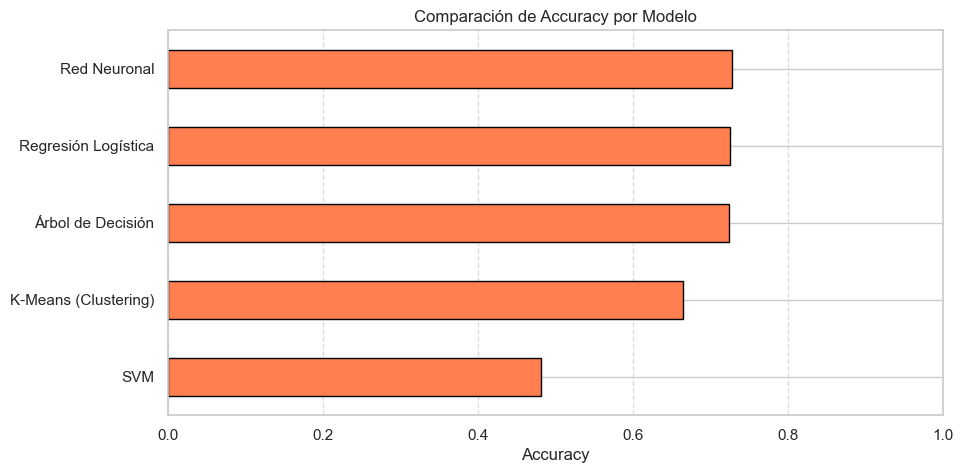

In [58]:
display(resultados_df.sort_values(by="Accuracy", ascending=False))

# Gráfico de barras
plt.figure(figsize=(10, 5))
resultados_df['Accuracy'].sort_values().plot(kind='barh', color='coral', edgecolor='black')
plt.title('Comparación de Accuracy por Modelo')
plt.xlabel('Accuracy')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

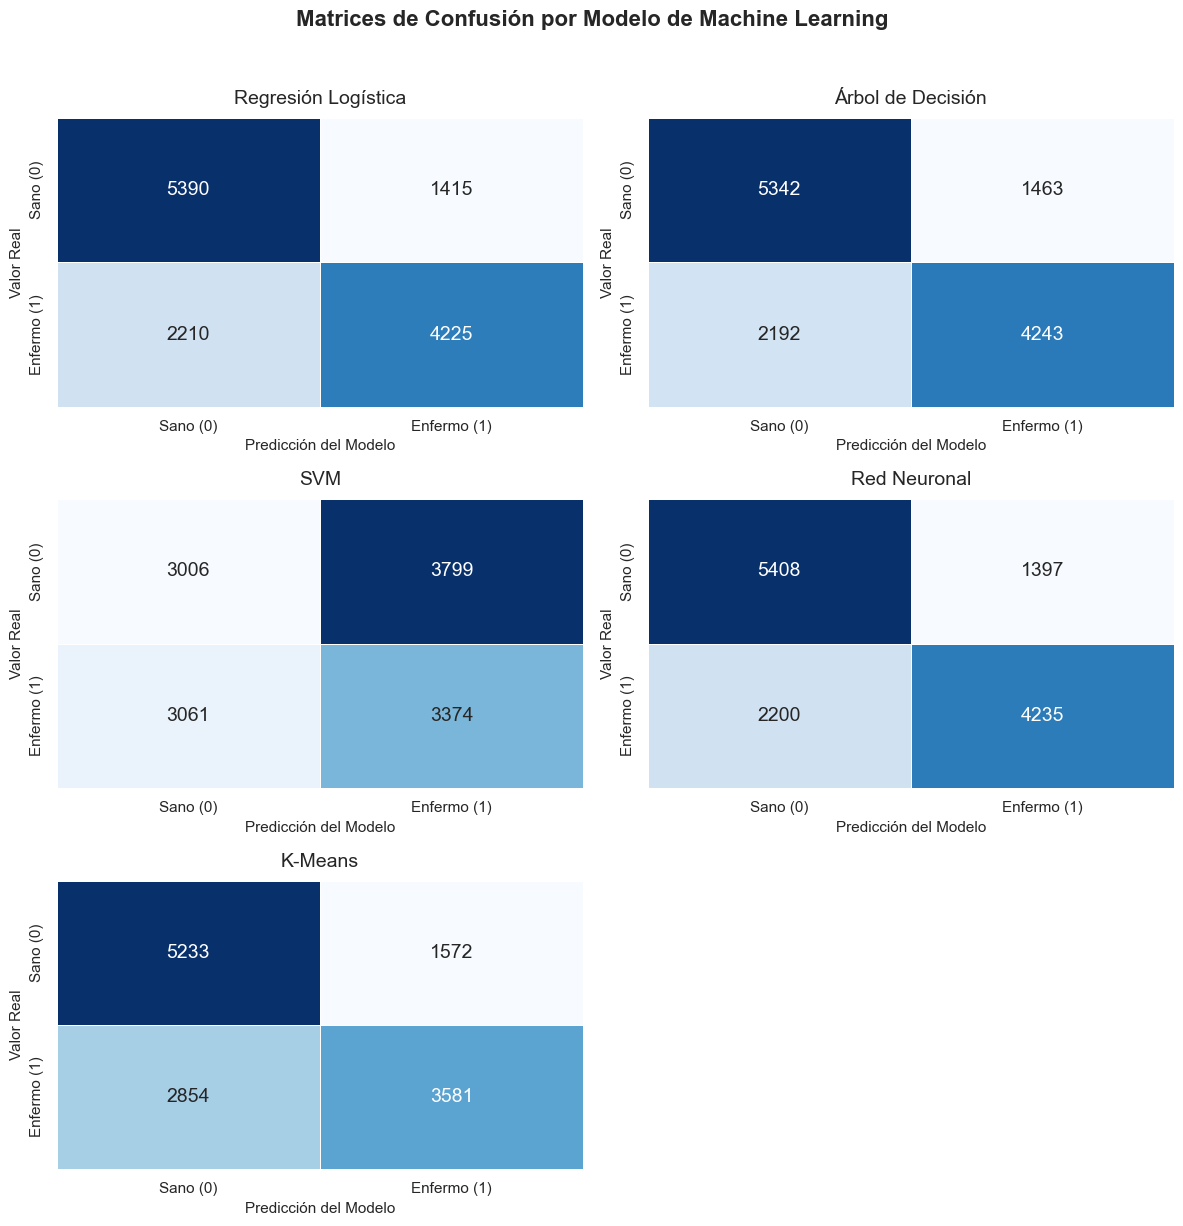

In [63]:
# Guardar todas las predicciones en un solo diccionario
diccionario_predicciones = {}

# Predicciones de modelos Scikit-Learn
for name, model in modelos.items():
    diccionario_predicciones[name] = model.predict(X_test)

# Predicciones de TensorFlow y K-Means 
diccionario_predicciones["Red Neuronal"] = y_pred_nn
diccionario_predicciones["K-Means"] = y_pred_kmeans

# Configurar la cuadrícula 
num_modelos = len(diccionario_predicciones)
filas = (num_modelos + 1) // 2 
columnas = 2

fig, axes = plt.subplots(nrows=filas, ncols=columnas, figsize=(12, 4 * filas))
fig.suptitle('Matrices de Confusión por Modelo de Machine Learning', fontsize=16, fontweight='bold', y=1.02)

axes = axes.flatten()

# Iterar sobre los modelos y generar cada matriz
for i, (nombre_modelo, predicciones) in enumerate(diccionario_predicciones.items()):
    
    # Calcular la matriz de confusión real vs predicción
    cm = confusion_matrix(y_test, predicciones)
    
    # Graficar usando seaborn heatmap
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=axes[i], 
                cbar=False, annot_kws={"size": 14}, linewidths=.5, edgecolor='gray')
    
    # Configurar títulos y etiquetas
    axes[i].set_title(nombre_modelo, fontsize=14, pad=10)
    axes[i].set_xlabel('Predicción del Modelo', fontsize=11)
    axes[i].set_ylabel('Valor Real', fontsize=11)
    
    # Cambiar los números 0 y 1 por texto para mejor lectura
    axes[i].xaxis.set_ticklabels(['Sano (0)', 'Enfermo (1)'])
    axes[i].yaxis.set_ticklabels(['Sano (0)', 'Enfermo (1)'])

if num_modelos < len(axes):
    for j in range(num_modelos, len(axes)):
        fig.delaxes(axes[j])

# Ajustar los espacios y mostrar
plt.tight_layout()
plt.show()